## 課題1:最急降下・Newton・BFGSを自作実装

In [4]:
import numpy as np


def f(x):
    return x[0]**2 + 10 * x[1]**2


def gradient(x):
    return np.array([2 * x[0], 20 * x[1]], dtype=float)


def hessian(x):
    return np.array([[2.0, 0.0], [0.0, 20.0]])


def backtracking_line_search(x, d, grad, alpha=1.0, beta=0.5, c=1e-4):
    while f(x + alpha * d) > f(x) + c * alpha * np.dot(grad, d):
        alpha *= beta
    return alpha


def gradient_descent(x_0=np.array([3.0, 2.0]), max_iter=100, eps=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < eps:
            return x, f(x), k, np.array(path)

        d = -grad
        alpha = backtracking_line_search(x, d, grad)
        x = x + alpha * d
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


def newton(x_0=np.array([3.0, 2.0]), max_iter=100, eps=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < eps:
            return x, f(x), k, np.array(path)

        d = np.linalg.solve(hessian(x), -grad)
        x = x + d
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


def BFGS(x_0=np.array([3.0, 2.0]), max_iter=100, eps=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    B = np.eye(len(x))  # ヘッセ行列の近似
    path = [x.copy()]

    for k in range(max_iter):
        grad = gradient(x)
        if np.linalg.norm(grad) < eps:
            return x, f(x), k, np.array(path)

        d = np.linalg.solve(B, -grad)
        alpha = backtracking_line_search(x, d, grad)
        s_k = (alpha * d).reshape(-1, 1)
        x_new = x + s_k.ravel()
        y_k = (gradient(x_new) - grad).reshape(-1, 1)

        sBs = (s_k.T @ B @ s_k).item()
        ys = (y_k.T @ s_k).item()
        if sBs > 1e-12 and ys > 1e-12:
            B = B - (B @ s_k @ s_k.T @ B) / sBs + (y_k @ y_k.T) / ys

        x = x_new
        path.append(x.copy())

    return x, f(x), max_iter, np.array(path)


--- 最急降下法 ---
最終解: [ 3.41261954e-07 -3.26993573e-08]
目的関数値: 1.2715220095e-13
反復回数: 63
最終勾配ノルム: 9.4527142819e-07


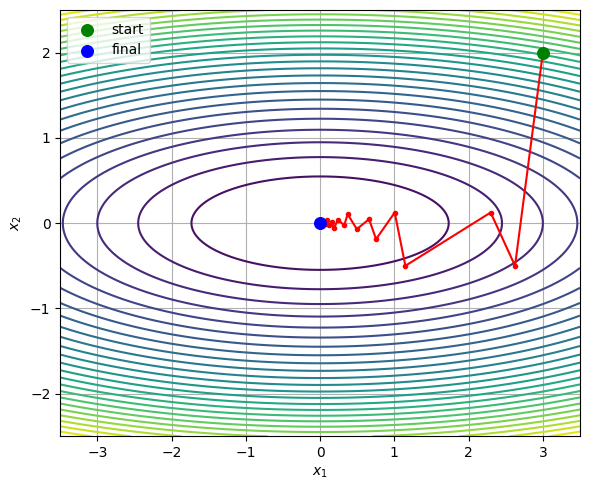

--- Newton法 ---
最終解: [0. 0.]
目的関数値: 0.0000000000e+00
反復回数: 1
最終勾配ノルム: 0.0000000000e+00


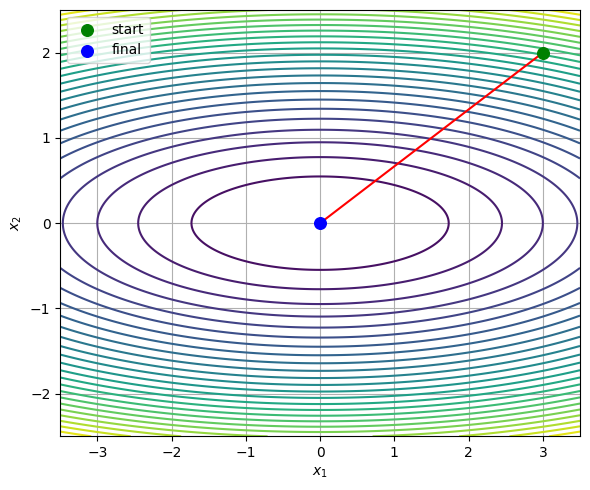

--- BFGS法 ---
最終解: [ 1.17808182e-08 -1.10472063e-10]
目的関数値: 1.3890971889e-16
反復回数: 6
最終勾配ノルム: 2.3665002496e-08


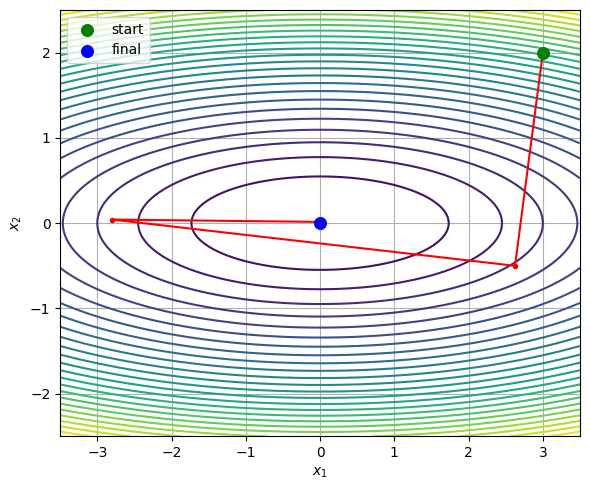

In [6]:
# 実行コード
import matplotlib.pyplot as plt
from pathlib import Path

x_0 = np.array([3.0, 2.0])
methods = {
    '最急降下法': gradient_descent,
    'Newton法': newton,
    'BFGS法': BFGS,
}

save_dir = Path('plots')
save_dir.mkdir(exist_ok=True)

x1 = np.linspace(-3.5, 3.5, 400)
x2 = np.linspace(-2.5, 2.5, 400)
X1, X2 = np.meshgrid(x1, x2)
Z = X1**2 + 10 * X2**2

for name, method in methods.items():
    x_final, f_final, iterations, path = method(x_0)
    grad_norm = np.linalg.norm(gradient(x_final))

    print(f'--- {name} ---')
    print(f'最終解: {x_final}')
    print(f'目的関数値: {f_final:.10e}')
    print(f'反復回数: {iterations}')
    print(f'最終勾配ノルム: {grad_norm:.10e}')

    plt.figure(figsize=(6, 5))
    plt.contour(X1, X2, Z, levels=25)
    plt.plot(path[:, 0], path[:, 1], 'o-', color='red', markersize=3)
    plt.scatter(path[0, 0], path[0, 1], color='green', s=70, label='start', zorder=3)
    plt.scatter(path[-1, 0], path[-1, 1], color='blue', s=70, label='final', zorder=3)
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_dir / f'kadai1_{name}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


## 課題2：初期値によって異なる解に収束することを体験


===== Initial point: (-4, 4) =====
[Gradient descent]
  最終解 x^*: [ 3.58442833 -1.84812653]
  f(x^*): 3.3467813814e-15
  反復回数: 40
[Newton]
  最終解 x^*: [-2.80511809  3.13131252]
  f(x^*): 1.3373083401e-22
  反復回数: 5
[BFGS]
  最終解 x^*: [ 3.58442834 -1.84812653]
  f(x^*): 8.4080770191e-21
  反復回数: 12


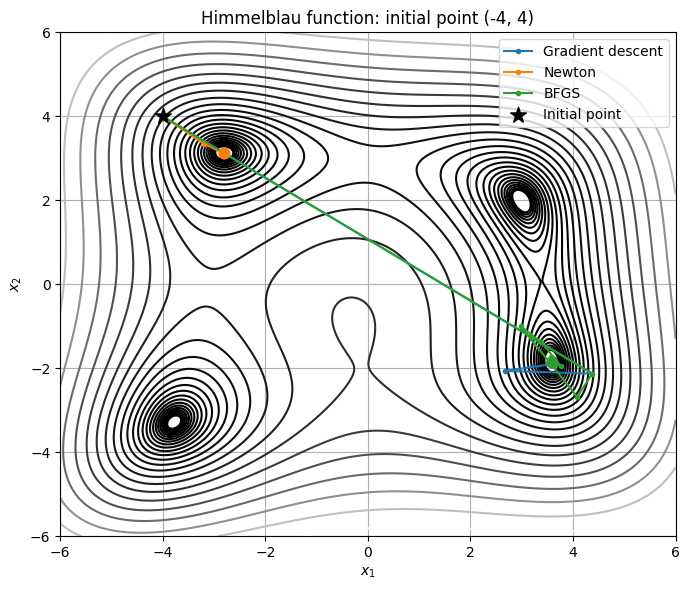


===== Initial point: (-3, -3) =====
[Gradient descent]
  最終解 x^*: [-3.77931025 -3.28318599]
  f(x^*): 4.2731108246e-17
  反復回数: 14
[Newton]
  最終解 x^*: [-3.77931025 -3.28318599]
  f(x^*): 3.3408182343e-22
  反復回数: 5
[BFGS]
  最終解 x^*: [-3.77931025 -3.28318599]
  f(x^*): 4.8332552061e-19
  反復回数: 9


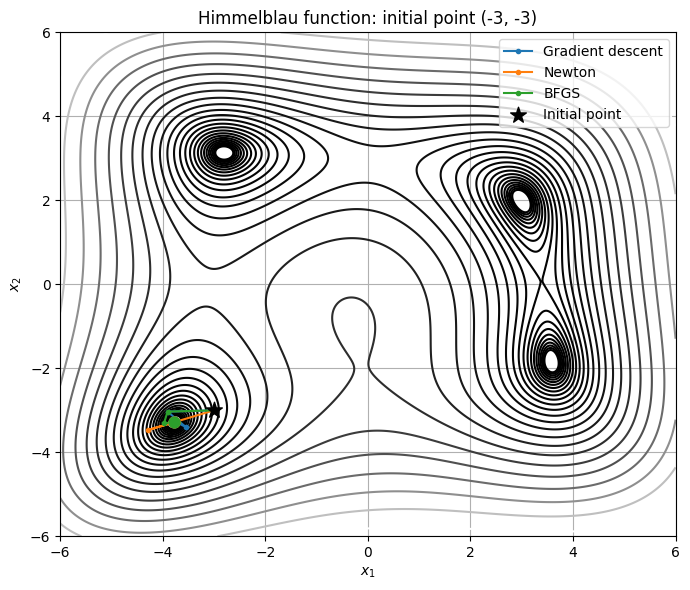


===== Initial point: (0, 0) =====
[Gradient descent]
  最終解 x^*: [3. 2.]
  f(x^*): 8.1902763580e-16
  反復回数: 25
[Newton]
  最終解 x^*: [-0.27084459 -0.92303856]
  f(x^*): 1.8161652152e+02
  反復回数: 4
[BFGS]
  最終解 x^*: [3. 2.]
  f(x^*): 1.4283529106e-19
  反復回数: 10


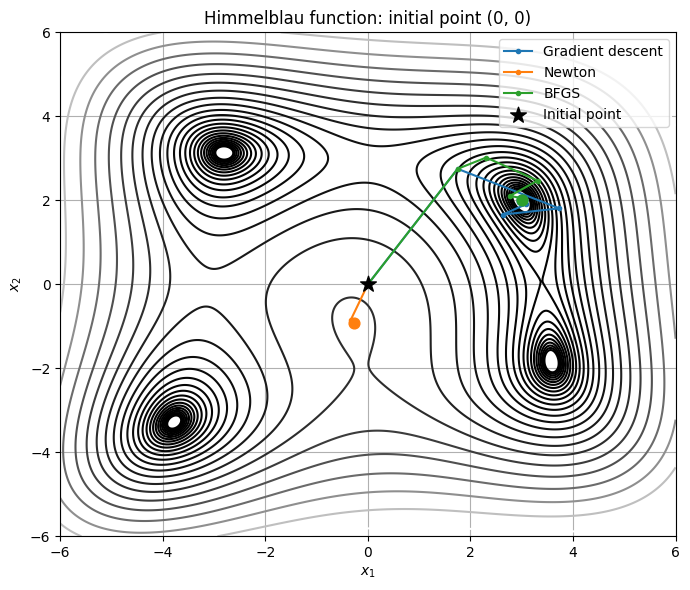


===== Initial point: (3, 3) =====
[Gradient descent]
  最終解 x^*: [2.99999999 2.00000001]
  f(x^*): 4.9070372104e-15
  反復回数: 21
[Newton]
  最終解 x^*: [3. 2.]
  f(x^*): 1.1164782589e-19
  反復回数: 5
[BFGS]
  最終解 x^*: [3. 2.]
  f(x^*): 5.5423532796e-18
  反復回数: 8


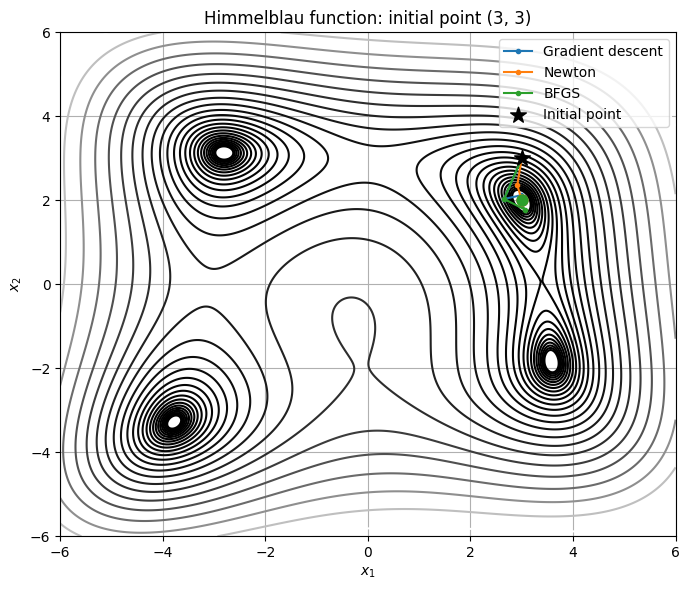


===== Initial point: (5, -2) =====
[Gradient descent]
  最終解 x^*: [-3.77931025 -3.28318599]
  f(x^*): 3.7073987628e-16
  反復回数: 13
[Newton]
  最終解 x^*: [ 3.58442834 -1.84812653]
  f(x^*): 5.1356012444e-24
  反復回数: 5
[BFGS]
  最終解 x^*: [-3.77931025 -3.28318598]
  f(x^*): 3.5197707153e-15
  反復回数: 11


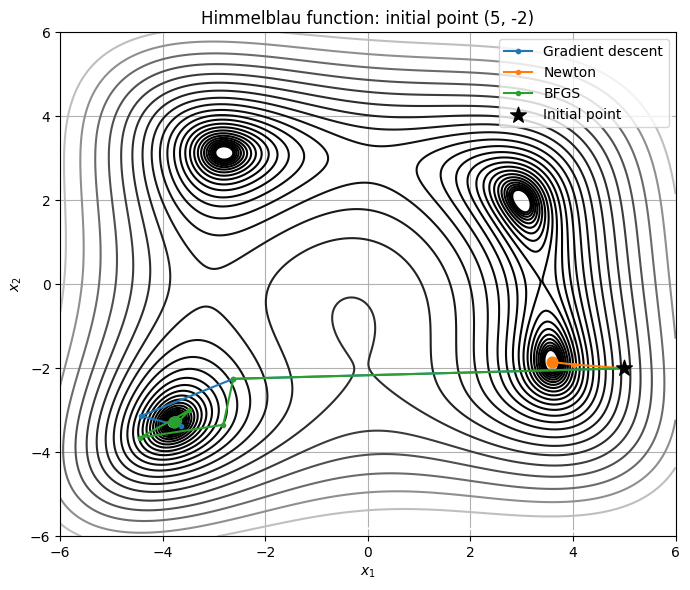

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def hb(x):
    first = (x[0]**2 + x[1] -11)**2
    second = (x[0] + x[1]**2 -7)**2

    return first + second

# Himmelblau関数の勾配とヘッセ行列
def hb_gradient(x):
    a = x[0]**2 + x[1] - 11
    b = x[0] + x[1]**2 - 7
    return np.array([4 * x[0] * a + 2 * b, 2 * a + 4 * x[1] * b])

def hb_hessian(x):
    return np.array([
        [12 * x[0]**2 + 4 * x[1] - 42, 4 * (x[0] + x[1])],
        [4 * (x[0] + x[1]), 4 * x[0] + 12 * x[1]**2 - 26]
    ])

def hb_line_search(x, d, grad, alpha=1.0, beta=0.5, c=1e-4):
    while hb(x + alpha * d) > hb(x) + c * alpha * np.dot(grad, d):
        alpha *= beta
    return alpha

def hb_gradient_descent(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = -grad
        alpha = hb_line_search(x, d, grad)
        x = x + alpha * d
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

def hb_newton(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = np.linalg.solve(hb_hessian(x), -grad)
        x = x + d
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

def hb_BFGS(x_0, max_iter=100, tol=1e-6):
    x = np.array(x_0, dtype=float, copy=True)
    B = np.eye(len(x))
    path = [x.copy()]
    for k in range(max_iter):
        grad = hb_gradient(x)
        if np.linalg.norm(grad) < tol:
            return x, hb(x), k, np.array(path)
        d = np.linalg.solve(B, -grad)
        alpha = hb_line_search(x, d, grad)
        s_k = (alpha * d).reshape(-1, 1)
        x_new = x + s_k.ravel()
        y_k = (hb_gradient(x_new) - grad).reshape(-1, 1)
        sBs = (s_k.T @ B @ s_k).item()
        ys = (y_k.T @ s_k).item()
        if sBs > 1e-12 and ys > 1e-12:
            B = B - (B @ s_k @ s_k.T @ B) / sBs + (y_k @ y_k.T) / ys
        x = x_new
        path.append(x.copy())
    return x, hb(x), max_iter, np.array(path)

# 初期値ごとに3手法を比較（経路図は5枚）
initial_points = [(-4, 4), (-3, -3), (0, 0), (3, 3), (5, -2)]
hb_methods = {
    'Gradient descent': hb_gradient_descent,
    'Newton': hb_newton,
    'BFGS': hb_BFGS
}

save_dir = Path('plots')
save_dir.mkdir(exist_ok=True)

x1 = np.linspace(-6, 6, 500)
x2 = np.linspace(-6, 6, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = (X1**2 + X2 - 11)**2 + (X1 + X2**2 - 7)**2

for point in initial_points:
    x_0 = np.array(point, dtype=float)
    plt.figure(figsize=(7, 6))
    plt.contour(X1, X2, Z, levels=np.logspace(0, 3, 25), cmap='gray')
    print(f'\n===== Initial point: {point} =====')

    for name, method in hb_methods.items():
        x_final, hb_final, iterations, path = method(x_0)
        grad_norm = np.linalg.norm(hb_gradient(x_final))
        print(f'[{name}]')
        print(f'  最終解 x^*: {x_final}')
        print(f'  f(x^*): {hb_final:.10e}')
        print(f'  反復回数: {iterations}')
        plt.plot(path[:, 0], path[:, 1], 'o-', markersize=3, label=name)
        plt.scatter(path[-1, 0], path[-1, 1], s=60, zorder=3)

    plt.scatter(x_0[0], x_0[1], color='black', marker='*', s=140,
                label='Initial point', zorder=4)
    plt.title(f'Himmelblau function: initial point {point}')
    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.xlim(-6, 6)
    plt.ylim(-6, 6)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(save_dir / f'himmelblau_{point[0]}_{point[1]}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


## 課題3：KKT条件を「有効制約集合」で実装する

In [9]:
# 課題3：KKT条件を有効制約集合で実装し、チェックリストを出力する
import numpy as np

def kkt_objective(x, center):
    return np.sum((x - center)**2)

def g(x):
    return np.array([x[0]**2 + x[1]**2 - 1, -x[0], -x[1]])

def grad_g(x):
    return [np.array([2*x[0], 2*x[1]]),
            np.array([-1.0, 0.0]), np.array([0.0, -1.0])]

def solve_active_set(center, active_set, max_iter=100, tol=1e-10):
    center = np.array(center, dtype=float)
    active_set = list(active_set)
    m = len(active_set)
    x = center.copy()

    if 0 in active_set:
        x = center / np.linalg.norm(center)
    if 1 in active_set:
        x[0] = 0.0
    if 2 in active_set:
        x[1] = 0.0
    if 0 in active_set and 1 in active_set:
        x = np.array([0.0, 1.0 if center[1] >= 0 else -1.0])
    if 0 in active_set and 2 in active_set:
        x = np.array([1.0 if center[0] >= 0 else -1.0, 0.0])

    z = np.r_[x, np.zeros(m)]
    for iteration in range(max_iter):
        x, mu = z[:2], z[2:]
        gradients = grad_g(x)
        stationarity = 2*(x - center)
        for j, i in enumerate(active_set):
            stationarity += mu[j]*gradients[i]
        F = np.r_[stationarity, g(x)[active_set]]
        
        if np.linalg.norm(F) < tol:
            mu_all = np.zeros(3)
            mu_all[active_set] = mu
            return x, mu_all, iteration

        H = 2*np.eye(2)
        if 0 in active_set:
            H += 2*mu[active_set.index(0)]*np.eye(2)
        G = np.column_stack([gradients[i] for i in active_set]) if m else np.empty((2, 0))
        J = np.block([[H, G], [G.T, np.zeros((m, m))]])
        try:
            z += np.linalg.solve(J, -F)
        except np.linalg.LinAlgError:
            return None
    return None

def verify_kkt_checklist(center, active_set, result, tol=1e-7):
    """資料9ページ目の5つのKKT判定チェックリストを評価する"""
    if result is None:
        return False, ["NG", "NG", "NG", "NG", "NG"]
        
    x, mu, _ = result
    gx = g(x)
    
    # 1. 主実行可能性: すべての制約で g_i(x*) <= 0
    c1 = np.all(gx <= tol)
    
    # 2. 有効制約の整合性: i ∈ A について g_i(x*) == 0
    c2 = all(abs(gx[i]) <= tol for i in active_set) if active_set else True
    
    # 3. 無効制約の整合性: i ∉ A について mu_i == 0
    c3 = all(abs(mu[i]) <= tol for i in range(3) if i not in active_set)
    
    # 4. 双対実行可能性: 有効制約の乗数 mu_i >= 0
    c4 = all(mu[i] >= -tol for i in active_set) if active_set else True
    
    # 5. 相補性: 全制約で mu_i * g_i(x*) == 0
    c5 = np.all(np.abs(mu * gx) <= tol)
    
    # 定常性 (停留条件: 勾配の和が0) も本来のKKT条件に必須なため内部判定として使用
    stationarity = 2*(x - np.array(center, dtype=float))
    for i in range(3):
        stationarity += mu[i]*grad_g(x)[i]
    c_stat = (np.linalg.norm(stationarity) <= tol)
    
    # すべて満たせば KKT OK
    is_valid = (c1 and c2 and c3 and c4 and c5 and c_stat)
    
    def to_str(cond): return "OK" if cond else "NG"
    checklist_strs = [to_str(c1), to_str(c2), to_str(c3), to_str(c4), to_str(c5)]
    
    return is_valid, checklist_strs

# --- 実行部分 ---
active_sets = [(), (0,), (1,), (2,), (0, 1), (0, 2), (1, 2)]
centers = [(2, 1), (-1, 1), (1, -1), (-1, -1)]
names = ['g1', 'g2', 'g3']

for center in centers:
    candidates = []
    print(f'\n======================================================')
    print(f' 中心点 (a, b) = {center}')
    print(f'======================================================')
    
    for A in active_sets:
        result = solve_active_set(center, A)
        label = '{' + ', '.join(names[i] for i in A) + '}'
        if label == '{}': label = '{φ}'
        
        is_valid, checklist = verify_kkt_checklist(center, A, result)
        
        status_str = '★KKT条件クリア (最適解候補)' if is_valid else '不適合'
        print(f'\n仮定した有効制約 A = {label:8s} -> {status_str}')
        
        if result is not None:
            print(f'  [チェックリスト]')
            print(f'  1. 主実行可能性   (全制約 g_i <= 0)         : {checklist[0]}')
            print(f'  2. 有効制約の整合性 (A内は g_i == 0)        : {checklist[1]}')
            print(f'  3. 無効制約の整合性 (A外は mu_i == 0)       : {checklist[2]}')
            print(f'  4. 双対実行可能性   (有効制約 mu_i >= 0)    : {checklist[3]}')
            print(f'  5. 相補性         (全制約 mu_i * g_i == 0): {checklist[4]}')
            
        if is_valid:
            x, mu, iteration = result
            candidates.append((kkt_objective(x, np.array(center)), x, mu, A))

    if candidates:
        value, x_star, mu_star, A_star = min(candidates, key=lambda item: item[0])
        print(f'\n>>> 結論: 中心点 {center} に対する最適解 <<<')
        print(f'  x* = {np.round(x_star, 4)}')
        print(f'  f(x*) = {value:.6f}')
        print(f'  正しい active set = {[names[i] for i in A_star]}')
        print(f'  乗数 μ = {np.round(mu_star, 4)}')
    else:
        print(f'\n>>> 最適解が見つかりませんでした <<<')


 中心点 (a, b) = (2, 1)

仮定した有効制約 A = {φ}      -> 不適合
  [チェックリスト]
  1. 主実行可能性   (全制約 g_i <= 0)         : NG
  2. 有効制約の整合性 (A内は g_i == 0)        : OK
  3. 無効制約の整合性 (A外は mu_i == 0)       : OK
  4. 双対実行可能性   (有効制約 mu_i >= 0)    : OK
  5. 相補性         (全制約 mu_i * g_i == 0): OK

仮定した有効制約 A = {g1}     -> ★KKT条件クリア (最適解候補)
  [チェックリスト]
  1. 主実行可能性   (全制約 g_i <= 0)         : OK
  2. 有効制約の整合性 (A内は g_i == 0)        : OK
  3. 無効制約の整合性 (A外は mu_i == 0)       : OK
  4. 双対実行可能性   (有効制約 mu_i >= 0)    : OK
  5. 相補性         (全制約 mu_i * g_i == 0): OK

仮定した有効制約 A = {g2}     -> 不適合
  [チェックリスト]
  1. 主実行可能性   (全制約 g_i <= 0)         : OK
  2. 有効制約の整合性 (A内は g_i == 0)        : OK
  3. 無効制約の整合性 (A外は mu_i == 0)       : OK
  4. 双対実行可能性   (有効制約 mu_i >= 0)    : NG
  5. 相補性         (全制約 mu_i * g_i == 0): OK

仮定した有効制約 A = {g3}     -> 不適合
  [チェックリスト]
  1. 主実行可能性   (全制約 g_i <= 0)         : NG
  2. 有効制約の整合性 (A内は g_i == 0)        : OK
  3. 無効制約の整合性 (A外は mu_i == 0)       : OK
  4. 双対実行可能性   (有効制約 mu_i >= 0)    : NG
  5. 相補性   